---
date: last-modified
---

# How to Plot Backscatter for CALIPSO

### Summary
The CALIPSO satellite uses LiDAR to measure clouds and aerosols in the atmosphere. This notebook shows how to extract backscatter data from CALIPSO and plot it over location and altitude. 

**NOTE:**

CALIPSO data is in the HDF4 format. In order to read HDF4 data in python, the `pyhdf` package is required. `Pyhdf` is no longer supported in updated versions of python. This code was tested in Python v3.6.15 and functions well.

### Prerequisites
- Python 3.6
- `numpy`
- `matplotlib`
- `datetime`
- `os`
- `pyhdf`

### Data Access
This notebook uses a file called: CAL_LID_L1-Standard-V4-51.2022-08-12T07-15-36ZN.hdf

You can find this file on this EARTHDATA Search site: 
https://search.earthdata.nasa.gov/search/granules?p=C2445512043-LARC_ASDC&pg[0][v]=f&pg[0][gsk]=-start_date&q=calipso&tl=1419119999.5!5!!

You can use any file in this collection in this notebook. When you download the file of your choosing, be sure to put it in an easily accessible location on your machine. 

You can browse through previews of CALIPSO data at the CALIPSO website here: https://www-calipso.larc.nasa.gov/products/lidar/browse_images/std_v451_index.php?d=2022

### Notebook Author / Affiliation

Laramie Plott / Atmospheric Science Data Center (ASDC)

## 1. Setup

- Import required packages. If you don't have them, run "pip install {package_name}" in your terminal.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib.colors import ListedColormap, LogNorm
from datetime import datetime, timedelta
import os

from pyhdf.SD import SD, SDC
from pyhdf.HDF import HDF

## 2. Set Working Directory, Read in Data File, and Set Variables
- Create folders to house data
- Assign directories and specified file(s)
- Assign variables based on the data headers in file
- Make sure the path leads to the folder where you want your plot to be exported

In [ ]:
cur_path = "/Users/{name}/Desktop/CALIPSO"
os.chdir(cur_path)
FILE_NAME = "CAL_LID_L1-Standard-V4-51.2022-08-12T07-15-36ZN.hdf"

In [ ]:
sd = SD(FILE_NAME, SDC.READ)
hdf = HDF(FILE_NAME)
vs = hdf.vstart()

- Select dataset objects for Backscatter, Time, and Latitude
- Depending on the file you may need to change the object names

In [ ]:
bsc_sds = sd.select("Total_Attenuated_Backscatter_532")
time_sds = sd.select("Profile_UTC_Time")
lat_sds = sd.select("Latitude")

- Select altitude

In [ ]:
xid = vs.find("metadata")
altid = vs.attach(xid)
altid.setfields("Lidar_Data_Altitudes")
nrecs, _, _, _, _ = altid.inquire()
altitude = altid.read(nRec=nrecs)
altid.detach()

- Check path to ensure you're in the right place

In [ ]:
print(cur_path)

# 3. Select Variables You Wish to Plot and Create Arrays for Formatting

- Convert to lists/arrays and reshape altitude
- Transpose and flip data to get arrays in proper format

In [ ]:
bsc_532nm_list = bsc_sds[:]
bsc_532nm = np.array(bsc_532nm_list)

time_list = time_sds[:].flatten()
time = np.array(time_list)

lat_list = lat_sds[:]
lat = np.array(lat_list)

alt = np.array(altitude[0][0])

min_log_val = 1e-10
bsc_532nm[bsc_532nm <= 0] = min_log_val

alt_reshaped = alt.reshape(583, 1)
alt_transposed = alt_reshaped.transpose()

bsc_flipped = np.flipud(bsc_532nm.T)

- Check shape of array 

In [ ]:
print(f"Read 'Integrated_Attenuated_Backscatter_532' with shape {bsc_flipped.shape}")
print(f"Read 'Profile_Time' with shape {time.shape}")
print(f"Read 'Latitudes' with shape {lat.shape}")
print(f"Read 'Reshaped_Lidar_Altitudes' with shape {alt_transposed.shape}")

# 4. Create Plot
- Create min/max bounds for altitude and latitude
- Create list of tick marks and labels
- Create color ramp to better visualize backscatter

In [ ]:
alt_min = np.min(alt_transposed)
alt_max = np.max(alt_transposed)
lat_min = np.min(lat)
lat_max = np.max(lat)

alt_ticks = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
lat_ticks = [29, 28.5, 28]
lat_ticks_labels = [
    ("29.00 \u00b0N \n62.40 \u00b0W  \n"),
    ("28.50 \u00b0N \n62.53 \u00b0W  \n"),
    ("28.00 \u00b0N \n62.66 \u00b0W  "),
]  # datapoint 9404, 9571, 9740   at 7:23:18, 7:23:27, 7:23:35

jet = cm.get_cmap("jet", 256)
newcolors = jet(np.linspace(0, 1, 256))
black = np.array([1 / 256, 1 / 256, 1 / 256, 1])
newcolors[:11, :] = black
newcmp = ListedColormap(newcolors)

- Build the plot
  - Set size and background color
  - Map data to axes object
  - Set axes labels and tick marks

C:\Users\ldplott\AppData\Roaming\Python\Python36\site-packages\ipykernel_launcher.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator


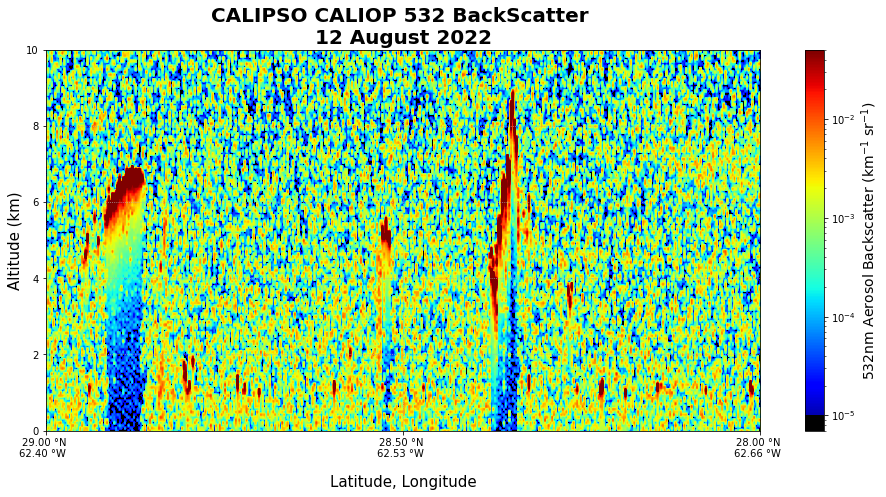

In [67]:
fig, ax = plt.subplots(figsize=(16, 7), facecolor="white")

my_norm = LogNorm(vmin=0.000007, vmax=0.05)

bsr_lat = ax.imshow(
    bsc_flipped,
    norm=my_norm,
    aspect="auto",
    cmap=newcmp,
    extent=(lat_max, lat_min, alt_max, alt_min),
)

ax.set(
    xlabel="Latitude, Longitude",
    ylabel="Altitude (km)",
    xticklabels=lat_ticks_labels,
    xticks=lat_ticks,
    yticks=alt_ticks,
)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)

cbar = plt.colorbar(bsr_lat, ax=ax)
cbar.set_label("532nm Aerosol Backscatter (km$^{-1}$ sr$^{-1}$)", size=14)

plt.title("CALIPSO CALIOP 532 BackScatter \n12 August 2022", fontweight="bold", fontsize="20")
plt.xlim([29, 28])
plt.ylim([0, 10])
plt.grid(linestyle=":")

plt.show()

- Save plot locally

In [ ]:
plt.savefig("CALIPSO_532nmExtinction_2022-8-12.png")

You have mapped backscatter to location and altitude! In the following cell blocks we are going to recreate the plot above with time instead of location as the x-axis. The time chosen for this plot is different than the location chosen above, so the output plot will be different by different by default.

# 5. Create Function to Convert Time to UTC
CALIPSO measures the time it takes data in terms of fraction of a day UTC (which looks like yymmdd.ffffffff for year, month, day, and fraction of a day), so this function converts time into full UTC format. 
  - Try several options to convert time
  - Print error if one occured
- Print results and convert time list to array

In [ ]:
def convert_time_data(time_values):
    """
    Converts time values from the fractional day format (yymmdd.ffffffff)
    to a list of datetime objects.
    """
    datetime_objects = []

    for index, t in enumerate(time_values[:]):
        try:
            date = int(t)
            fractional_day = t - date

            str_date = str(date)

            date_object = datetime.strptime(str_date, "%y%m%d")

            fractional_day_float = float(fractional_day)
            delta = timedelta(days=fractional_day_float)

            new_datetime = date_object + delta
            datetime_objects.append(new_datetime)

        except Exception as e:
            print(f"\n[{index}] An error occurred: {e}")
            print(f"Values at error: t={t}, date={date}, fractional_day={fractional_day}")
            return datetime_objects

    return datetime_objects


datetime_list = convert_time_data(time)
datetime_array = np.array(datetime_list)

# 7.Create New Plot with Latitude Instead of Time
  - Create Tick Values & Labels 
  - Create extent of the plot 

In [ ]:
time_ticks = [
    datetime(2022, 8, 12, 7, 15),
    datetime(2022, 8, 12, 7, 30),
    datetime(2022, 8, 12, 7, 45),
    datetime(2022, 8, 12, 8),
]

time_min = mdates.date2num(np.min(datetime_list))
time_max = mdates.date2num(np.max(datetime_list))
alt_min = np.min(alt_transposed)
alt_max = np.max(alt_transposed)

- Generate new plot

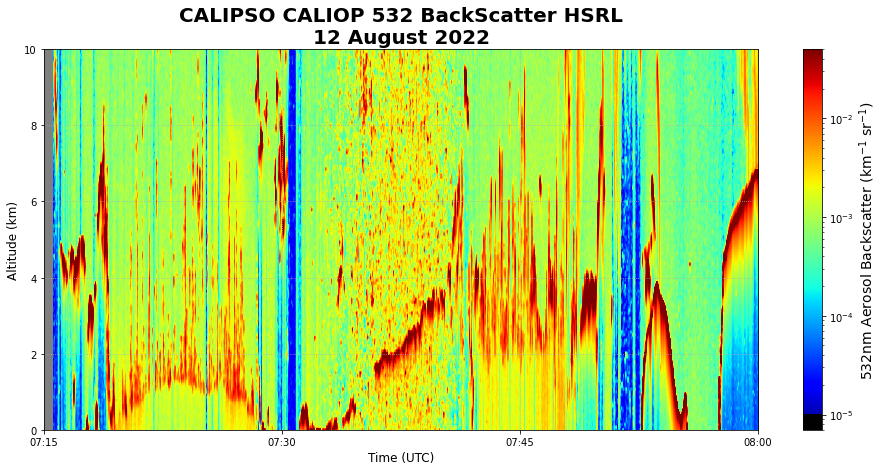

In [71]:
fig2, ax2 = plt.subplots(figsize=(16, 7), facecolor="white")

bsr2 = ax2.imshow(
    bsc_flipped,
    norm=my_norm,
    aspect="auto",
    cmap=newcmp,
    extent=(time_min, time_max, alt_max, alt_min),
)

ax2.xaxis_date()
ax2.set_facecolor("gray")
date_format = mdates.DateFormatter("%H:%M")
ax2.xaxis.set_major_formatter(date_format)
ax2.set(xlabel="Time (UTC)", ylabel="Altitude (km)", xticks=time_ticks, yticks=alt_ticks)
ax2.xaxis.label.set_size(12)
ax2.yaxis.label.set_size(12)

cbar2 = plt.colorbar(bsr2, ax=ax2)
cbar2.set_label("532nm Aerosol Backscatter (km$^{-1}$ sr$^{-1}$)", size=14)

plt.title("CALIPSO CALIOP 532 BackScatter HSRL\n12 August 2022", fontweight="bold", fontsize="20")
plt.xlim([datetime(2022, 8, 12, 7, 15), datetime(2022, 8, 12, 8)])
plt.ylim([0, 10])
plt.grid(linestyle=":")

plt.show()

- Save plot locally 

In [ ]:
plt.savefig("CALIPSO_532nmExtinction_2022-8-12.png")